In [72]:
from pathlib import Path
import pandas as pd

# 設定 data 目錄路徑
data_dir = Path("../data")

# 儲存結果的列表
valid_ids = []
id_info = []

# 掃描所有子目錄
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir() and not folder.name.startswith('.'):
        folder_id = folder.name
        
        # 檢查是否同時存在 image.png 和 annotation.png（或 label.png）
        has_image = (folder / "image.png").exists()
        # has_annotation = (folder / "annotation.png").exists()
        has_label = (folder / "label.png").exists()
        
        # 記錄詳細資訊
        info = {
            'ID': folder_id,
            'has_image': has_image,
            'valid': has_image and has_label
        }
        id_info.append(info)
        
        # 如果同時有 image 和 label，加入有效列表
        if has_image and has_label:
            valid_ids.append(folder_id)

# 建立 DataFrame 方便查看
df = pd.DataFrame(id_info)

print(f"總共掃描了 {len(id_info)} 個 ID")
print(f"同時包含 image 和 label 的 ID 數量: {len(valid_ids)}")
print(f"\n統計:")
print(f"  - 有 image.png: {df['has_image'].sum()}")
print(f"  - 有效的 ID: {df['valid'].sum()}")

# 顯示前 10 個有效的 ID
print(f"\n前 10 個有效的 ID:")
for i, valid_id in enumerate(valid_ids[:10], 1):
    print(f"  {i}. {valid_id}")

# 顯示完整的統計表格
df.head(10)

總共掃描了 266 個 ID
同時包含 image 和 label 的 ID 數量: 17

統計:
  - 有 image.png: 266
  - 有效的 ID: 17

前 10 個有效的 ID:
  1. S1140-2_a
  2. S1140-2_b
  3. S1585-2_a
  4. S1585-2_b
  5. S1616-2_a
  6. S222-2_a
  7. S222-2_b
  8. S226-2_a
  9. S226-2_b
  10. S236-2_a


,ID,has_image,valid
0,S1037-2_a,True,False
1,S1037-2_b,True,False
2,S1140-2_a,True,True
3,S1140-2_b,True,True
4,S1196-2_a,True,False
5,S1196-2_b,True,False
6,S1233-2_a,True,False
7,S1233-2_b,True,False
8,S1262-2_a,True,False
9,S1262-2_b,True,False


In [73]:
import cv2
import numpy as np
from tqdm import tqdm

# 設定切片參數
PATCH_SIZE = 128
OVERLAY = 16
STRIDE = PATCH_SIZE - OVERLAY  # 224

# 輸出目錄
output_dir = Path("../data_patches")
output_dir.mkdir(exist_ok=True)

(output_dir / "images").mkdir(exist_ok=True)
(output_dir / "labels").mkdir(exist_ok=True)

print(f"切片設定:")
print(f"  - Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"  - Overlay: {OVERLAY} pixels")
print(f"  - Stride: {STRIDE} pixels")
print(f"\n輸出目錄: {output_dir}")
print(f"  - images/")
print(f"  - labels/")

切片設定:
  - Patch size: 128x128
  - Overlay: 16 pixels
  - Stride: 112 pixels

輸出目錄: ../data_patches
  - images/
  - labels/


In [81]:
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt

def create_soft_label(binary_mask, sigma=1.5, max_radius=5):
    """
    從二值遮罩創建基於中心線衰減的軟標籤
    
    Args:
        binary_mask: 二值遮罩 (0 或 255)
        sigma: 衰減參數，控制從中心線衰減的速度
        max_radius: 最大半徑，超過此距離的像素設為 0
    
    Returns:
        soft_label: 軟標籤，值在 [0, 1] 範圍內
    """
    # 轉換為二值 (True/False)
    binary_mask = (binary_mask > 0)
    
    # 如果遮罩全為 0，直接返回
    if not np.any(binary_mask):
        return np.zeros_like(binary_mask, dtype=np.float32)
    
    # 提取骨架（中心線）
    skeleton = skeletonize(binary_mask)
    
    # 計算到骨架的距離
    dist_from_skeleton = distance_transform_edt(~skeleton)
    
    # 使用指數衰減生成軟標籤
    soft_label = np.exp(-dist_from_skeleton / sigma)
    
    # 超過最大半徑的設為 0
    soft_label[dist_from_skeleton > max_radius] = 0
    
    # 只保留原始遮罩範圍內的值（可選，可以註釋掉以允許擴展）
    # soft_label = soft_label * binary_mask
    
    return soft_label.astype(np.float32)

def extract_patches(image, label, patch_size=512, stride=480, sigma=1.5, max_radius=5):
    """
    從大圖中提取固定大小的 patches，並生成軟標籤
    
    Args:
        image: 原始圖片 (H, W)
        label: 標註圖片 (H, W)
        patch_size: patch 的大小
        stride: 滑動窗口的步長
        sigma: 軟標籤衰減參數
        max_radius: 軟標籤最大半徑
    
    Returns:
        patches: list of (image_patch, label_patch, position)
    """
    patches = []
    h, w = label.shape[:2]
    
    # 計算需要切分的次數
    y_positions = list(range(0, h - patch_size + 1, stride))
    x_positions = list(range(0, w - patch_size + 1, stride))
    
    # 確保包含右邊和底部的邊緣
    if len(y_positions) > 0 and y_positions[-1] + patch_size < h:
        y_positions.append(h - patch_size)
    if len(x_positions) > 0 and x_positions[-1] + patch_size < w:
        x_positions.append(w - patch_size)
    
    for y in y_positions:
        for x in x_positions:
            # 提取 patch
            img_patch = image[y:y+patch_size, x:x+patch_size]
            lbl_patch = label[y:y+patch_size, x:x+patch_size]
            
            # 驗證 patch 形狀是否正確
            if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                continue
            if lbl_patch.shape[0] != patch_size or lbl_patch.shape[1] != patch_size:
                continue
            
            # 檢查 patch 是否為空
            if img_patch.size == 0 or lbl_patch.size == 0:
                continue
            
            # 檢查 label patch 是否有值（不是全為 0）
            if np.any(lbl_patch > 0):
                # 生成軟標籤
                soft_label_patch = create_soft_label(lbl_patch, sigma=sigma, max_radius=max_radius)
                
                patches.append({
                    'image': img_patch.copy(),
                    'label': soft_label_patch.copy(),  # 使用軟標籤
                    'position': (y, x)
                })
    
    return patches

print("✅ 切片函數已定義（使用基於中心線衰減的軟標籤）")
print(f"   參數: sigma={1.5}, max_radius={5}")

✅ 切片函數已定義（使用基於中心線衰減的軟標籤）
   參數: sigma=1.5, max_radius=5


In [112]:
# 處理所有有效的 ID
total_patches = 0
patch_statistics = []

# 軟標籤參數
SIGMA = 1.5  # 衰減參數
MAX_RADIUS =  100  # 最大半徑（像素）

print(f"開始處理 {len(valid_ids)} 個有效的 ID...")
print(f"軟標籤參數: sigma={SIGMA}, max_radius={MAX_RADIUS}\n")

for idx, folder_id in enumerate(tqdm(valid_ids), 1):
    folder_path = data_dir / folder_id
    
    # 讀取圖片
    image_path = folder_path / "image.png"
    label_path = folder_path / "label.png"
    
    # 檢查 label.png 是否存在，不存在就跳過
    if not label_path.exists():
        print(f"⚠️  找不到 label.png，跳過: {folder_id}")
        continue
    
    # 讀取 image (BGR format)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        print(f"⚠️  無法讀取 {image_path}")
        continue
    
    # 只提取綠色通道 (BGR format 中，索引 1 是綠色)
    image = image_bgr[:, :, 1]  # 提取綠色通道，結果是灰度圖 (H, W)
    
    # 讀取 label
    label = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
    if label is None:
        print(f"⚠️  無法讀取 label: {folder_id}")
        continue
    
    # 將 label resize 到與 image 相同的尺寸
    if label.shape != image.shape:
        label = cv2.resize(label, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # 提取 patches（包含軟標籤生成）
    patches = extract_patches(image, label, PATCH_SIZE, STRIDE, sigma=SIGMA, max_radius=MAX_RADIUS)
    
    # 保存 patches
    for patch_idx, patch_data in enumerate(patches):
        # 生成文件名: {ID}_{patch_idx}_{y}_{x}.png
        y, x = patch_data['position']
        filename = f"{folder_id}_patch{patch_idx:03d}_y{y}_x{x}.png"
        
        # 再次驗證 patch 不為空且形狀正確
        img_patch = patch_data['image']
        lbl_patch = patch_data['label']  # 這是軟標籤，值在 [0, 1]
        
        if img_patch.size == 0 or lbl_patch.size == 0:
            print(f"⚠️  跳過空 patch: {filename}")
            continue
        
        if img_patch.shape[0] != PATCH_SIZE or img_patch.shape[1] != PATCH_SIZE:
            print(f"⚠️  跳過形狀不正確的 image patch: {filename}, shape={img_patch.shape}")
            continue
        
        # 保存 image patch (綠色通道，灰度圖)
        success = cv2.imwrite(str(output_dir / "images" / filename), img_patch)
        if not success:
            print(f"⚠️  保存 image patch 失敗: {filename}")
            continue
        
        # 保存 label patch（軟標籤，需要轉換為 uint8）
        # 將 [0, 1] 映射到 [0, 255]
        lbl_patch_uint8 = (lbl_patch * 255).astype(np.uint8)
        cv2.imwrite(str(output_dir / "labels" / filename), lbl_patch_uint8)
    
    # 統計信息
    patch_statistics.append({
        'ID': folder_id,
        'image_shape': f"{image.shape[0]}x{image.shape[1]}",
        'num_patches': len(patches)
    })
    
    total_patches += len(patches)

print(f"\n✅ 處理完成！")
print(f"   總共生成 {total_patches} 個有效的 patches")
if len(valid_ids) > 0:
    print(f"   平均每個 ID 生成 {total_patches / len(valid_ids):.1f} 個 patches")
print(f"   軟標籤已保存為 uint8 格式（需要在讀取時除以 255）")

開始處理 17 個有效的 ID...
軟標籤參數: sigma=1.5, max_radius=100



100%|██████████| 17/17 [00:02<00:00,  8.12it/s]


✅ 處理完成！
   總共生成 1193 個有效的 patches
   平均每個 ID 生成 70.2 個 patches
   軟標籤已保存為 uint8 格式（需要在讀取時除以 255）


每個 ID 的 patch 數量統計:

       ID image_shape  num_patches
S1140-2_a   1947x4716           98
S1140-2_b   1944x5644          113
S1585-2_a   2867x5632           91
S1585-2_b   1946x5632           98
S1616-2_a   1024x3789           46
 S222-2_a   1026x3791           58
 S222-2_b   1027x4717           54
 S226-2_a   1024x3789           45
 S226-2_b   1026x4720           47
 S236-2_a   1026x3793           89
 S236-2_b   1026x4713           70
 S341-2_a   1027x5639           83
 S341-2_b   1028x5637            0
 S487-2_a   1026x4716           95
 S487-2_b   1027x4714           75
 S558-2_a   1026x4716           80
 S558-2_b   1026x3794           51


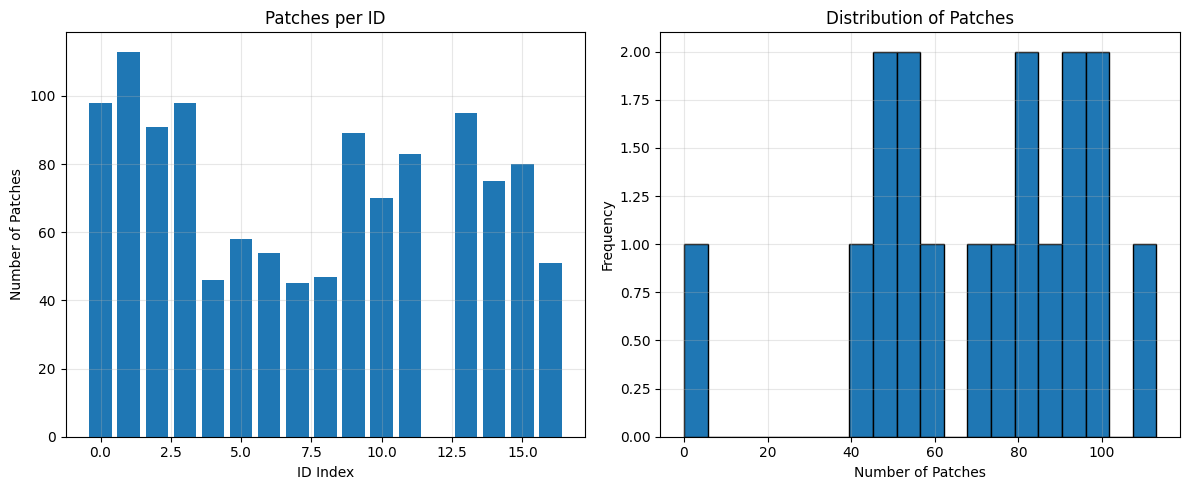


✅ 統計信息已保存到: ../data_patches/patch_statistics.csv


In [113]:
# 顯示詳細統計
import matplotlib.pyplot as plt

stats_df = pd.DataFrame(patch_statistics)
print("每個 ID 的 patch 數量統計:\n")
print(stats_df.to_string(index=False))

# 繪製統計圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(stats_df)), stats_df['num_patches'])
plt.xlabel('ID Index')
plt.ylabel('Number of Patches')
plt.title('Patches per ID')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(stats_df['num_patches'], bins=20, edgecolor='black')
plt.xlabel('Number of Patches')
plt.ylabel('Frequency')
plt.title('Distribution of Patches')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 保存統計信息
stats_df.to_csv(output_dir / "patch_statistics.csv", index=False)
print(f"\n✅ 統計信息已保存到: {output_dir / 'patch_statistics.csv'}")

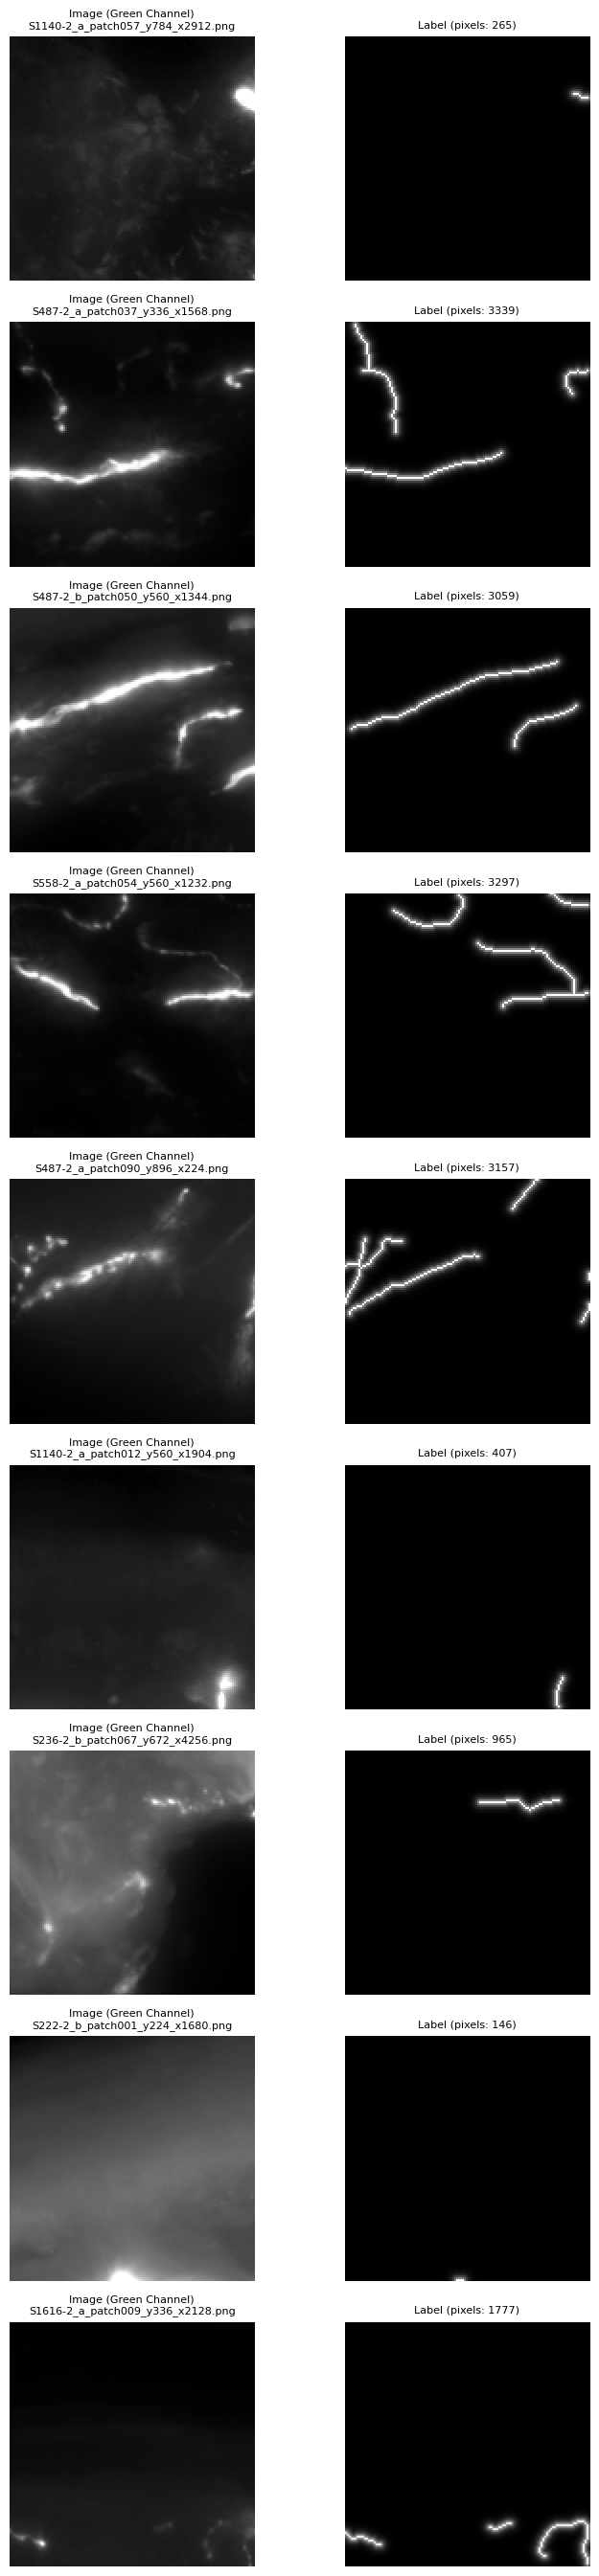

顯示了 9 個隨機 patches 的示例


In [114]:
# 可視化一些示例 patches
import random

# 隨機選擇一些 patches 來顯示
patch_files = list((output_dir / "images").glob("*.png"))
num_samples = min(9, len(patch_files))
sample_files = random.sample(patch_files, num_samples)

fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 3))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for idx, img_file in enumerate(sample_files):
    filename = img_file.name
    
    # 讀取對應的文件
    img = cv2.imread(str(output_dir / "images" / filename), cv2.IMREAD_GRAYSCALE)  # 綠色通道灰度圖
    lbl = cv2.imread(str(output_dir / "labels" / filename), cv2.IMREAD_GRAYSCALE)
    
    # 顯示
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title(f"Image (Green Channel)\n{filename}", fontsize=8)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(lbl, cmap='gray')
    axes[idx, 1].set_title(f"Label (pixels: {np.sum(lbl > 0)})", fontsize=8)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"顯示了 {num_samples} 個隨機 patches 的示例")

In [115]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ 已導入 PyTorch 相關模組")

✅ 已導入 PyTorch 相關模組


In [116]:
class NerveFiberDataset(Dataset):
    """
    神經纖維圖像數據集（支持軟標籤）
    """
    def __init__(self, data_dir, transform=None, normalize=True):
        """
        Args:
            data_dir: patch 數據目錄 (包含 images/ 和 labels/ 子目錄)
            transform: Albumentations 數據增強
            normalize: 是否標準化圖像到 [0, 1]
        """
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.normalize = normalize
        
        # 獲取所有 image 文件
        self.image_files = sorted(list((self.data_dir / "images").glob("*.png")))
        
        print(f"找到 {len(self.image_files)} 個 patches")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # 讀取 image
        img_path = self.image_files[idx]
        image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        # 讀取對應的 label（軟標籤）
        label_path = self.data_dir / "labels" / img_path.name
        label = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
        
        # 將軟標籤從 uint8 [0, 255] 轉換回 float32 [0, 1]
        label = label.astype(np.float32) / 255.0
        
        # 應用數據增強
        if self.transform:
            augmented = self.transform(image=image, mask=label)
            image = augmented['image']
            label = augmented['mask']
        
        # 標準化圖像到 [0, 1]
        if self.normalize and not self.transform:
            image = image.astype(np.float32) / 255.0
        
        # 轉換為 tensor
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float()
            if len(image.shape) == 2:
                image = image.unsqueeze(0)  # 添加 channel 維度 (1, H, W)
        
        if not isinstance(label, torch.Tensor):
            label = torch.from_numpy(label).float()
            if len(label.shape) == 2:
                label = label.unsqueeze(0)  # 添加 channel 維度 (1, H, W)
        
        return {
            'image': image,
            'label': label,  # 軟標籤，值在 [0, 1]
            'filename': img_path.name
        }

print("✅ NerveFiberDataset 類別已定義（支持軟標籤）")

✅ NerveFiberDataset 類別已定義（支持軟標籤）


In [117]:
# 定義數據增強
train_transform = A.Compose([
    # 幾何變換
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.5
    ),
    
    # 亮度和對比度增強
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    
    # 添加噪聲
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    
    # 標準化和轉換為 tensor
    A.Normalize(mean=[0.5], std=[0.5]),  # 標準化到 [-1, 1]
    ToTensorV2()
])

# 驗證集不需要數據增強，只做標準化
val_transform = A.Compose([
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2()
])

print("✅ 數據增強已定義")
print("   訓練集: 翻轉、旋轉、縮放、亮度/對比度調整、添加噪聲")
print("   驗證集: 只做標準化")

✅ 數據增強已定義
   訓練集: 翻轉、旋轉、縮放、亮度/對比度調整、添加噪聲
   驗證集: 只做標準化


/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_49588/1882857958.py:7: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipykernel_49588/1882857958.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [118]:
# 創建完整數據集
full_dataset = NerveFiberDataset(
    data_dir=output_dir,
    transform=None,  # 先不使用 transform 來測試
    normalize=True
)

# 劃分訓練集和驗證集 (80% 訓練, 20% 驗證)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # 設置隨機種子以確保可重複性
)

print(f"數據集劃分:")
print(f"  訓練集: {len(train_dataset)} 個 patches")
print(f"  驗證集: {len(val_dataset)} 個 patches")
print(f"  總計: {len(full_dataset)} 個 patches")

找到 1193 個 patches
數據集劃分:
  訓練集: 954 個 patches
  驗證集: 239 個 patches
  總計: 1193 個 patches


In [119]:
# 創建 DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print(f"DataLoader 已創建:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  訓練集 batches: {len(train_loader)}")
print(f"  驗證集 batches: {len(val_loader)}")
print(f"  Num workers: {NUM_WORKERS}")

DataLoader 已創建:
  Batch size: 32
  訓練集 batches: 29
  驗證集 batches: 8
  Num workers: 4


Batch shape:
  Images: torch.Size([32, 1, 128, 128])
  Labels: torch.Size([32, 1, 128, 128])

Image statistics:
  Min: 0.0157
  Max: 0.9961
  Mean: 0.2507

Label statistics:
  Min: 0.0000
  Max: 1.0000
  Positive pixels ratio: 0.0293


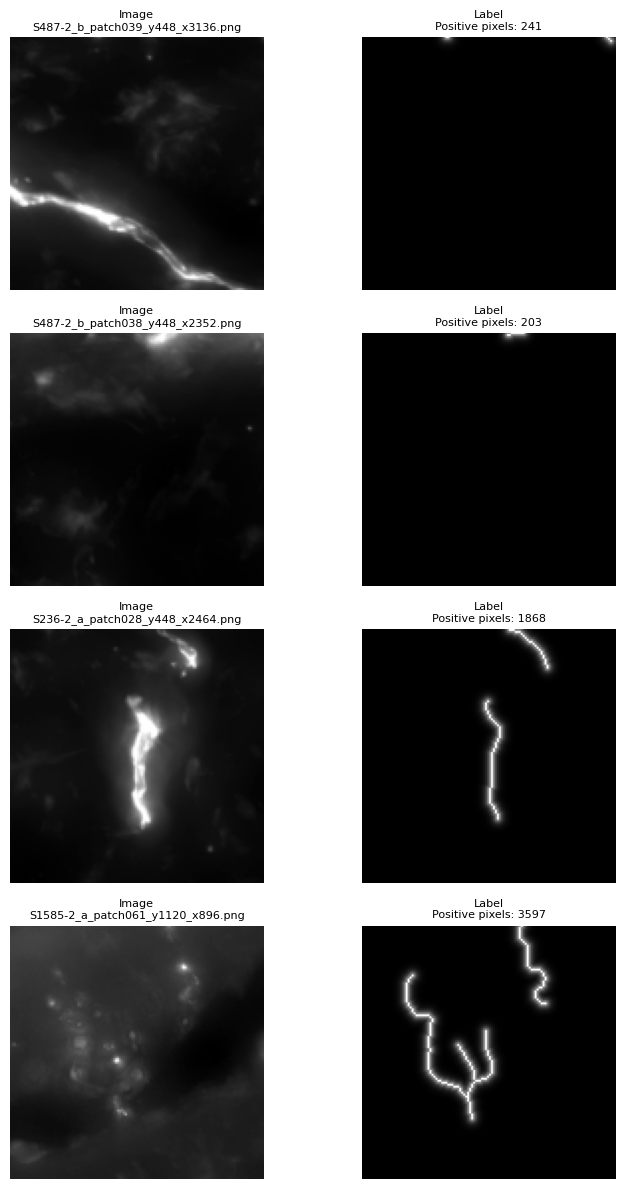


✅ DataLoader 測試成功！


In [120]:
# 測試 DataLoader 並可視化一個 batch
batch = next(iter(train_loader))
images = batch['image']
labels = batch['label']
filenames = batch['filename']

print(f"Batch shape:")
print(f"  Images: {images.shape}")  # (B, 1, H, W)
print(f"  Labels: {labels.shape}")  # (B, 1, H, W)
print(f"\nImage statistics:")
print(f"  Min: {images.min().item():.4f}")
print(f"  Max: {images.max().item():.4f}")
print(f"  Mean: {images.mean().item():.4f}")
print(f"\nLabel statistics:")
print(f"  Min: {labels.min().item():.4f}")
print(f"  Max: {labels.max().item():.4f}")
print(f"  Positive pixels ratio: {labels.mean().item():.4f}")

# 可視化前 4 個樣本
num_display = min(4, BATCH_SIZE)
fig, axes = plt.subplots(num_display, 2, figsize=(8, num_display * 3))
if num_display == 1:
    axes = axes.reshape(1, -1)

for i in range(num_display):
    img = images[i, 0].cpu().numpy()  # (H, W)
    lbl = labels[i, 0].cpu().numpy()  # (H, W)
    
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Image\n{filenames[i]}", fontsize=8)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(lbl, cmap='gray')
    axes[i, 1].set_title(f"Label\nPositive pixels: {np.sum(lbl > 0)}", fontsize=8)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ DataLoader 測試成功！")

In [121]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# 檢查是否有 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 創建 U-Net 模型，使用 ResNet34 作為預訓練的 encoder
model = smp.Unet(
    encoder_name="resnet34",        # 使用 ResNet34 作為 encoder
    encoder_weights="imagenet",     # 使用 ImageNet 預訓練權重
    in_channels=1,                  # 輸入是單通道灰度圖
    classes=1,                      # 輸出 1 個類別（二分類）
    activation=None                 # 不使用激活函數，在損失函數中處理
)

model = model.to(device)

# 顯示模型信息
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型架構: U-Net with ResNet34 encoder")
print(f"  總參數量: {total_params:,}")
print(f"  可訓練參數: {trainable_params:,}")
print(f"  輸入: (B, 1, 256, 256)")
print(f"  輸出: (B, 1, 256, 256)")
print(f"\n✅ 模型已創建並加載 ImageNet 預訓練權重")

使用設備: cuda

模型架構: U-Net with ResNet34 encoder
  總參數量: 24,430,097
  可訓練參數: 24,430,097
  輸入: (B, 1, 256, 256)
  輸出: (B, 1, 256, 256)

✅ 模型已創建並加載 ImageNet 預訓練權重


In [122]:
# 定義損失函數（適合軟標籤）

# 1. MSE Loss - 直接回歸軟標籤值
mse_loss = nn.MSELoss()

# 2. L1 Loss - 對異常值更魯棒
l1_loss = nn.L1Loss()

# 3. BCE Loss（仍然適用於軟標籤）
bce_loss = nn.BCEWithLogitsLoss()

def soft_dice_loss(pred, target, smooth=1e-5):
    """
    適用於軟標籤的 Soft Dice Loss
    """
    pred = torch.sigmoid(pred)  # 轉換為概率
    
    # 展平
    pred = pred.view(-1)
    target = target.view(-1)
    
    # 計算 Dice coefficient
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return 1 - dice

def combined_loss(pred, target):
    """
    組合損失函數，適合軟標籤:
    - Soft Dice Loss: 關注重疊區域
    - MSE Loss: 精確匹配軟標籤值
    - L1 Loss: 對異常值魯棒
    """
    # 對於 MSE 和 L1，需要先將 pred 轉換為概率
    pred_prob = torch.sigmoid(pred)
    
    # 計算各個損失
    dice = soft_dice_loss(pred, target)
    mse = mse_loss(pred_prob, target)
    l1 = l1_loss(pred_prob, target)
    
    # 組合損失（可以調整權重）
    return mse + l1

# 定義優化器
LEARNING_RATE = 1e-4
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

# 定義學習率調度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("損失函數和優化器配置（適合軟標籤）:")
print(f"  損失函數: Soft Dice Loss + MSE Loss + L1 Loss")
print(f"  - Soft Dice Loss: 關注重疊區域")
print(f"  - MSE Loss (0.5x): 精確匹配軟標籤值")
print(f"  - L1 Loss (0.3x): 對異常值魯棒")
print(f"  優化器: AdamW")
print(f"  學習率: {LEARNING_RATE}")
print(f"  Weight decay: 1e-5")
print(f"  學習率調度器: ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"\n✅ 訓練配置已完成（支持軟標籤）")

損失函數和優化器配置（適合軟標籤）:
  損失函數: Soft Dice Loss + MSE Loss + L1 Loss
  - Soft Dice Loss: 關注重疊區域
  - MSE Loss (0.5x): 精確匹配軟標籤值
  - L1 Loss (0.3x): 對異常值魯棒
  優化器: AdamW
  學習率: 0.0001
  Weight decay: 1e-5
  學習率調度器: ReduceLROnPlateau (patience=5, factor=0.5)

✅ 訓練配置已完成（支持軟標籤）


In [123]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    訓練一個 epoch
    """
    model.train()
    total_loss = 0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        # 前向傳播
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向傳播
        loss.backward()
        optimizer.step()
        
        # 記錄
        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / num_batches
    return avg_loss

def validate(model, dataloader, criterion, device):
    """
    驗證模型
    """
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for batch in pbar:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            # 前向傳播
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 記錄
            total_loss += loss.item()
            num_batches += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / num_batches
    return avg_loss

print("✅ 訓練和驗證函數已定義")

✅ 訓練和驗證函數已定義


In [127]:
# 訓練參數
NUM_EPOCHS = 100
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(exist_ok=True)

# 記錄訓練歷史
history = {
    'train_loss': [],
    'val_loss': []
}

best_val_loss = float('inf')

print(f"開始訓練...")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  模型保存目錄: {SAVE_DIR}")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # 訓練
    train_loss = train_one_epoch(model, train_loader, combined_loss, optimizer, device)
    history['train_loss'].append(train_loss)
    
    # 驗證
    val_loss = validate(model, val_loader, combined_loss, device)
    history['val_loss'].append(val_loss)
    
    # 學習率調度
    scheduler.step(val_loss)
    
    # 顯示結果
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_path = SAVE_DIR / "best_model.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, best_model_path)
        print(f"  ✅ 最佳模型已保存！ (val_loss: {val_loss:.4f})")
    
    # 每 10 個 epoch 保存一次檢查點
    if (epoch + 1) % 10 == 0:
        checkpoint_path = SAVE_DIR / f"checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, checkpoint_path)
        print(f"  💾 檢查點已保存: {checkpoint_path.name}")

print("\n" + "="*60)
print(f"✅ 訓練完成！")
print(f"   最佳驗證損失: {best_val_loss:.4f}")
print(f"   最佳模型位置: {SAVE_DIR / 'best_model.pth'}")

開始訓練...
  Epochs: 100
  模型保存目錄: ../models

Epoch 1/100


Validation: 100%|██████████| 8/8 [00:00<00:00, 49.47it/s, loss=0.0423]


  Train Loss: 0.0333
  Val Loss: 0.0377
  ✅ 最佳模型已保存！ (val_loss: 0.0377)

Epoch 2/100


Validation: 100%|██████████| 8/8 [00:00<00:00, 50.98it/s, loss=0.0378]


  Train Loss: 0.0327
  Val Loss: 0.0366
  ✅ 最佳模型已保存！ (val_loss: 0.0366)

Epoch 3/100


...

  Train Loss: 0.0129
  Val Loss: 0.0273

Epoch 99/100


Validation: 100%|██████████| 8/8 [00:00<00:00, 53.26it/s, loss=0.0266]


  Train Loss: 0.0129
  Val Loss: 0.0273

Epoch 100/100


Validation: 100%|██████████| 8/8 [00:00<00:00, 51.71it/s, loss=0.0276]


  Train Loss: 0.0128
  Val Loss: 0.0278
  💾 檢查點已保存: checkpoint_epoch_100.pth

✅ 訓練完成！
   最佳驗證損失: 0.0269
   最佳模型位置: ../models/best_model.pth


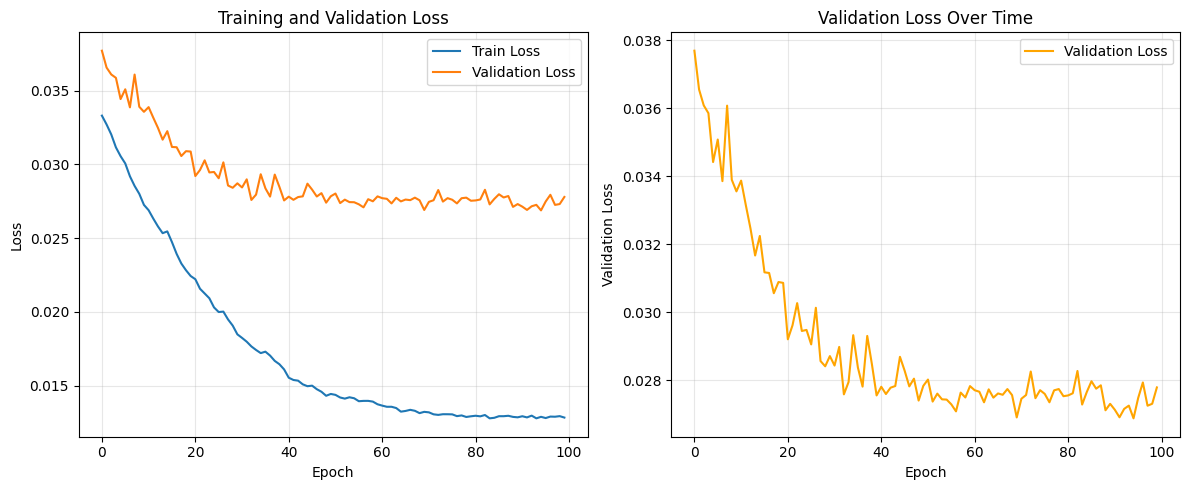

✅ 訓練歷史圖已保存到: ../models/training_history.png


In [128]:
# 繪製訓練歷史
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ 訓練歷史圖已保存到: {SAVE_DIR / 'training_history.png'}")

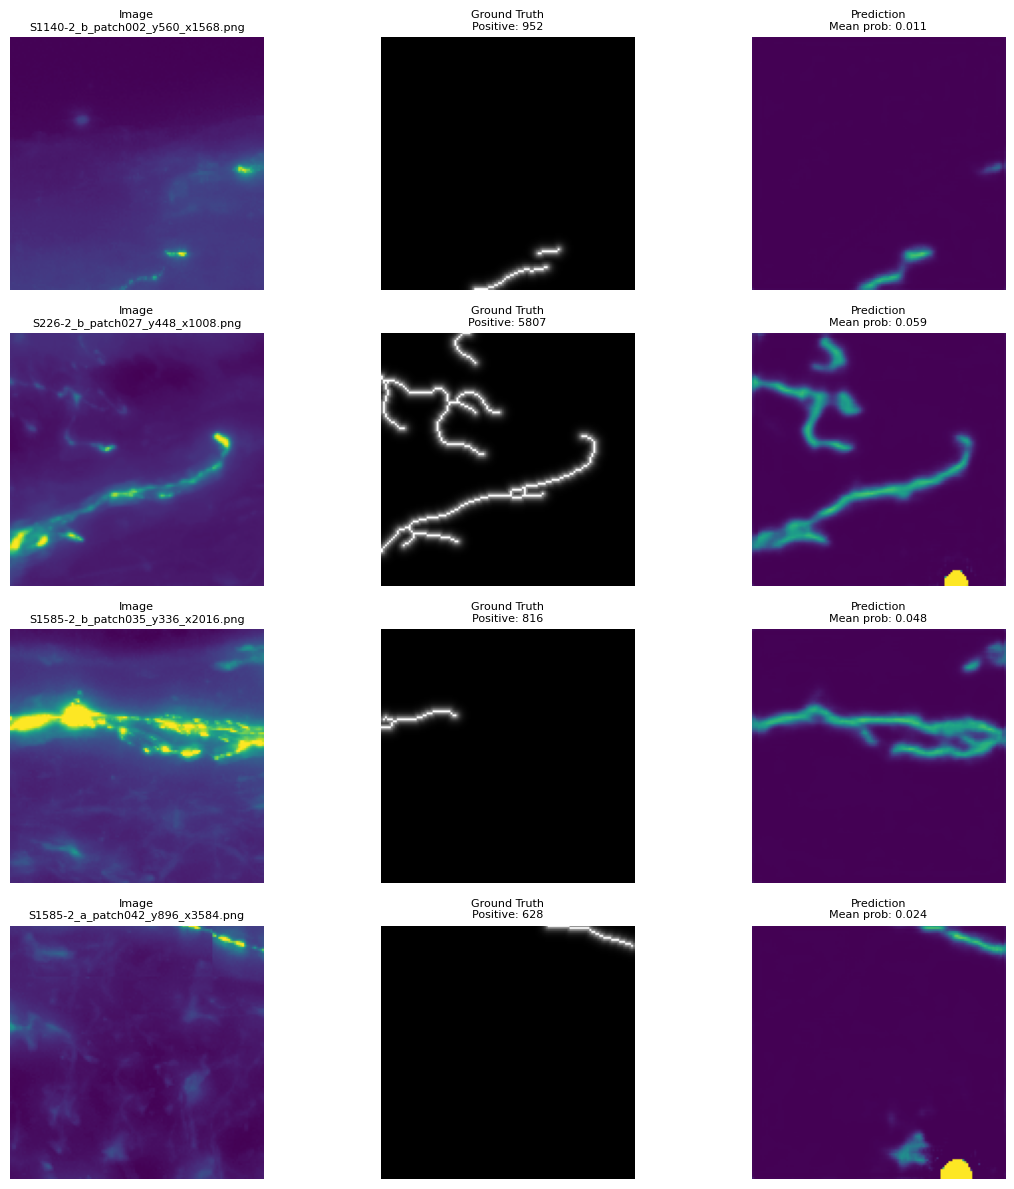

✅ 預測結果已保存到: ../models/prediction_samples.png


In [130]:
# 可視化模型預測結果
model.eval()

# 從驗證集中獲取一個 batch
val_batch = next(iter(val_loader))
images = val_batch['image'].to(device)
labels = val_batch['label'].to(device)
filenames = val_batch['filename']

# 預測
with torch.no_grad():
    predictions = model(images)
    predictions = torch.sigmoid(predictions)  # 轉換為概率

# 可視化前 4 個樣本
num_display = min(4, len(images))
fig, axes = plt.subplots(num_display, 3, figsize=(12, num_display * 3))
if num_display == 1:
    axes = axes.reshape(1, -1)

for i in range(num_display):
    img = images[i, 0].cpu().numpy()
    lbl = labels[i, 0].cpu().numpy()
    pred = predictions[i, 0].cpu().numpy()
    
    # 原始圖像
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image\n{filenames[i]}", fontsize=8)
    axes[i, 0].axis('off')
    
    # Ground truth
    axes[i, 1].imshow(lbl, cmap='gray')
    axes[i, 1].set_title(f"Ground Truth\nPositive: {np.sum(lbl > 0)}", fontsize=8)
    axes[i, 1].axis('off')
    
    # 預測結果
    axes[i, 2].imshow(pred, vmin=0, vmax=1)
    axes[i, 2].set_title(f"Prediction\nMean prob: {pred.mean():.3f}", fontsize=8)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(SAVE_DIR / "prediction_samples.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ 預測結果已保存到: {SAVE_DIR / 'prediction_samples.png'}")

In [131]:
import re

def reconstruct_image_from_patches(sample_id, patch_dir, image_type='images'):
    """
    從 patches 重建完整圖像
    
    Args:
        sample_id: 樣本 ID（如 'S1585-2_a'）
        patch_dir: patches 目錄
        image_type: 'images' 或 'labels'
    
    Returns:
        reconstructed: 重建的完整圖像
    """
    patch_dir = Path(patch_dir)
    
    # 找到所有屬於該樣本的 patches
    pattern = f"{sample_id}_patch*.png"
    patch_files = sorted((patch_dir / image_type).glob(pattern))
    
    if len(patch_files) == 0:
        print(f"找不到樣本 {sample_id} 的 patches")
        return None
    
    print(f"找到 {len(patch_files)} 個 patches")
    
    # 解析文件名獲取位置信息和 patch 尺寸
    positions = []
    max_y, max_x = 0, 0
    patch_size = None
    
    for patch_file in patch_files:
        # 文件名格式: {ID}_patch{idx:03d}_y{y}_x{x}.png
        match = re.search(r'_y(\d+)_x(\d+)\.png$', patch_file.name)
        if match:
            y, x = int(match.group(1)), int(match.group(2))
            positions.append((y, x, patch_file))
            max_y = max(max_y, y)
            max_x = max(max_x, x)
            
            # 讀取第一個 patch 來確定尺寸
            if patch_size is None:
                patch = cv2.imread(str(patch_file), cv2.IMREAD_GRAYSCALE)
                patch_size = patch.shape[0]  # 假設是正方形
    
    # 計算重建圖像的尺寸
    img_height = max_y + patch_size
    img_width = max_x + patch_size
    
    print(f"重建圖像尺寸: {img_height} x {img_width}")
    print(f"Patch 尺寸: {patch_size} x {patch_size}")
    
    # 創建空白畫布
    reconstructed = np.zeros((img_height, img_width), dtype=np.float32)
    count_map = np.zeros((img_height, img_width), dtype=np.float32)  # 記錄每個像素被覆蓋的次數
    
    # 將 patches 放到對應位置（處理重疊區域）
    for y, x, patch_file in positions:
        patch = cv2.imread(str(patch_file), cv2.IMREAD_GRAYSCALE).astype(np.float32)
        
        # 對於 labels，需要除以 255 恢復軟標籤
        if image_type == 'labels':
            patch = patch / 255.0
        
        # 累加到重建圖像
        reconstructed[y:y+patch_size, x:x+patch_size] += patch
        count_map[y:y+patch_size, x:x+patch_size] += 1
    
    # 處理重疊區域：取平均值
    reconstructed = np.divide(reconstructed, count_map, where=count_map > 0)
    
    # 對於非 labels，轉換回 uint8
    if image_type == 'images':
        reconstructed = reconstructed.astype(np.uint8)
    
    return reconstructed

# 重建 S1585-2_a 的圖像和標籤
sample_id = 'S1585-2_a'

print(f"正在重建樣本: {sample_id}\n")
print("="*60)

# 重建 image
print("\n重建 Image:")
reconstructed_image = reconstruct_image_from_patches(sample_id, output_dir, 'images')

# 重建 label
print("\n重建 Label (軟標籤):")
reconstructed_label = reconstruct_image_from_patches(sample_id, output_dir, 'labels')

print("\n" + "="*60)
print("✅ 重建完成！")

正在重建樣本: S1585-2_a


重建 Image:
找到 91 個 patches
重建圖像尺寸: 2256 x 5056
Patch 尺寸: 128 x 128

重建 Label (軟標籤):
找到 91 個 patches
重建圖像尺寸: 2256 x 5056
Patch 尺寸: 128 x 128

✅ 重建完成！


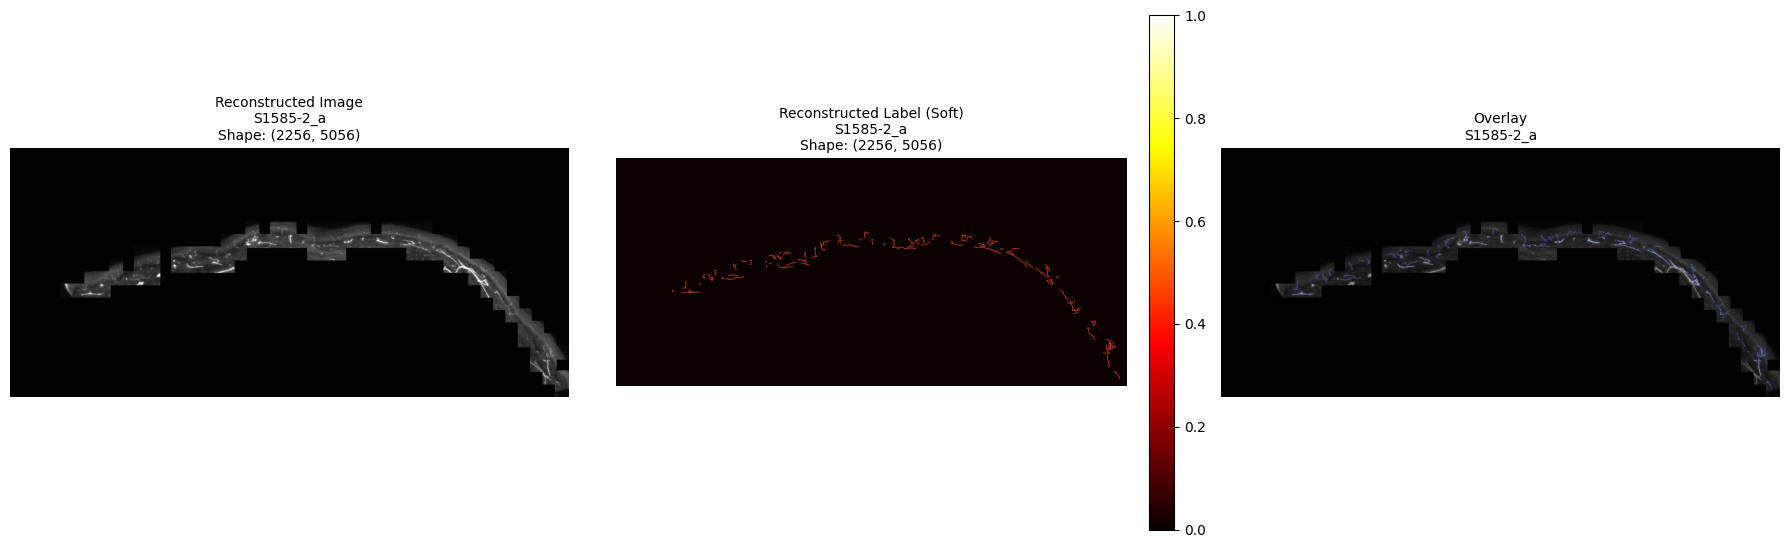


✅ 重建圖像已保存到: ../data_patches/S1585-2_a_reconstructed.png

統計信息:
  Image 尺寸: (2256, 5056)
  Image 範圍: [0, 254]
  Label 尺寸: (2256, 5056)
  Label 範圍: [0.0000, 1.0000]
  Label 非零像素: 151009


In [132]:
# 可視化重建的完整圖像
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 顯示重建的 image
axes[0].imshow(reconstructed_image, cmap='gray')
axes[0].set_title(f'Reconstructed Image\n{sample_id}\nShape: {reconstructed_image.shape}', fontsize=10)
axes[0].axis('off')

# 顯示重建的 label（軟標籤）
im1 = axes[1].imshow(reconstructed_label, cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'Reconstructed Label (Soft)\n{sample_id}\nShape: {reconstructed_label.shape}', fontsize=10)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 顯示疊加圖
overlay = reconstructed_image.copy()
if overlay.dtype != np.uint8:
    overlay = (overlay * 255).astype(np.uint8)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_GRAY2RGB)

# 將軟標籤疊加為熱圖
label_colored = (reconstructed_label * 255).astype(np.uint8)
label_colored = cv2.applyColorMap(label_colored, cv2.COLORMAP_HOT)
overlay_rgb = cv2.addWeighted(overlay_rgb, 0.6, label_colored, 0.4, 0)

axes[2].imshow(overlay_rgb)
axes[2].set_title(f'Overlay\n{sample_id}', fontsize=10)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(output_dir / f"{sample_id}_reconstructed.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 重建圖像已保存到: {output_dir / f'{sample_id}_reconstructed.png'}")
print(f"\n統計信息:")
print(f"  Image 尺寸: {reconstructed_image.shape}")
print(f"  Image 範圍: [{reconstructed_image.min()}, {reconstructed_image.max()}]")
print(f"  Label 尺寸: {reconstructed_label.shape}")
print(f"  Label 範圍: [{reconstructed_label.min():.4f}, {reconstructed_label.max():.4f}]")
print(f"  Label 非零像素: {np.sum(reconstructed_label > 0)}")

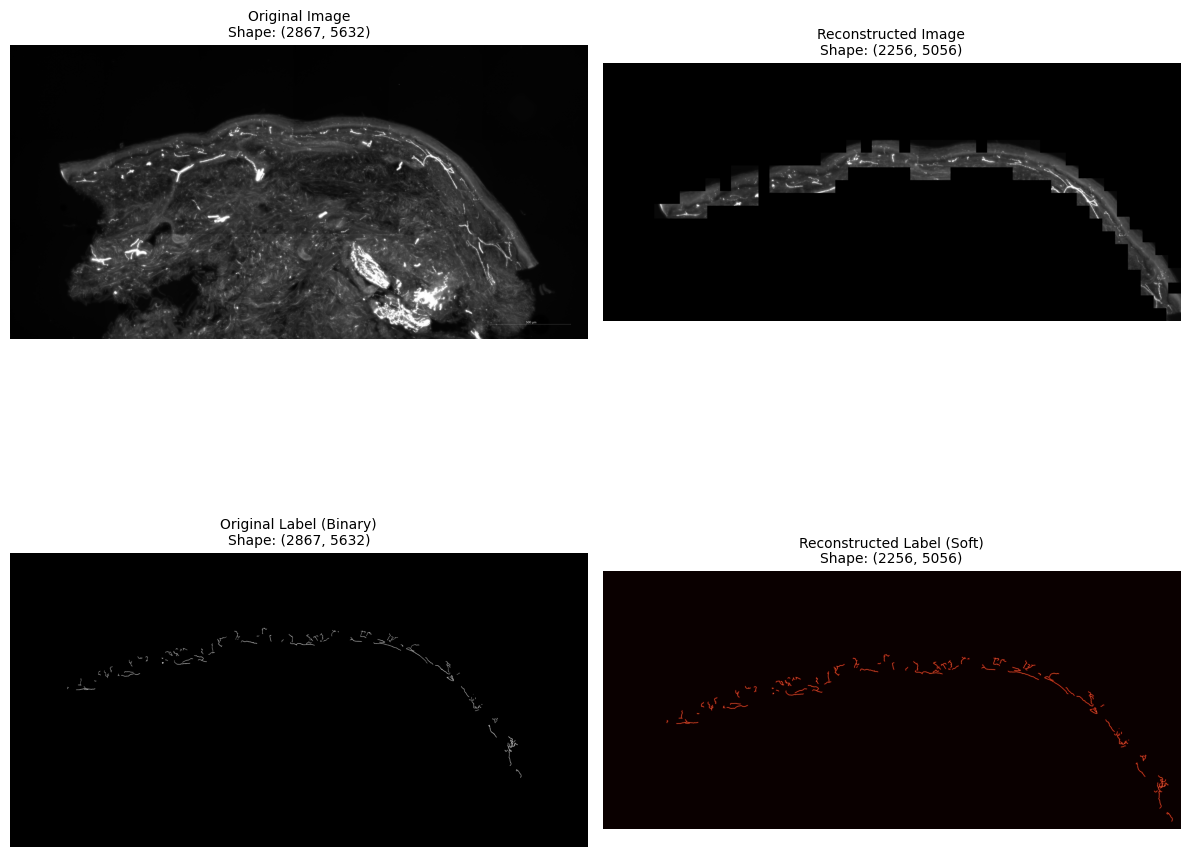

✅ 比較圖已保存到: ../data_patches/S1585-2_a_comparison.png

尺寸比較:
  原始圖像: (2867, 5632)
  重建圖像: (2256, 5056)
  原始標籤: (2867, 5632)
  重建標籤: (2256, 5056)


In [133]:
# 可選：與原始圖像比較
original_image_path = data_dir / sample_id / "image.png"
original_label_path = data_dir / sample_id / "label.png"

if original_image_path.exists():
    # 讀取原始圖像
    original_image_bgr = cv2.imread(str(original_image_path))
    original_image = original_image_bgr[:, :, 1] if original_image_bgr is not None else None  # 綠色通道
    
    # 讀取原始 label
    original_label = cv2.imread(str(original_label_path), cv2.IMREAD_GRAYSCALE) if original_label_path.exists() else None
    
    if original_image is not None and original_label is not None:
        # 將原始 label resize 到與 image 相同尺寸
        if original_label.shape != original_image.shape:
            original_label = cv2.resize(original_label, (original_image.shape[1], original_image.shape[0]), 
                                       interpolation=cv2.INTER_NEAREST)
        
        # 比較圖
        fig, axes = plt.subplots(2, 2, figsize=(12, 12))
        
        # 原始 image
        axes[0, 0].imshow(original_image, cmap='gray')
        axes[0, 0].set_title(f'Original Image\nShape: {original_image.shape}', fontsize=10)
        axes[0, 0].axis('off')
        
        # 重建 image
        axes[0, 1].imshow(reconstructed_image, cmap='gray')
        axes[0, 1].set_title(f'Reconstructed Image\nShape: {reconstructed_image.shape}', fontsize=10)
        axes[0, 1].axis('off')
        
        # 原始 label
        axes[1, 0].imshow(original_label, cmap='gray')
        axes[1, 0].set_title(f'Original Label (Binary)\nShape: {original_label.shape}', fontsize=10)
        axes[1, 0].axis('off')
        
        # 重建 label（軟標籤）
        axes[1, 1].imshow(reconstructed_label, cmap='hot', vmin=0, vmax=1)
        axes[1, 1].set_title(f'Reconstructed Label (Soft)\nShape: {reconstructed_label.shape}', fontsize=10)
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig(output_dir / f"{sample_id}_comparison.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"✅ 比較圖已保存到: {output_dir / f'{sample_id}_comparison.png'}")
        print(f"\n尺寸比較:")
        print(f"  原始圖像: {original_image.shape}")
        print(f"  重建圖像: {reconstructed_image.shape}")
        print(f"  原始標籤: {original_label.shape}")
        print(f"  重建標籤: {reconstructed_label.shape}")
    else:
        print("⚠️  無法讀取原始圖像或標籤")
else:
    print(f"⚠️  找不到原始圖像: {original_image_path}")

In [ ]:
def calculate_dice_coefficient(pred, target, threshold=0.5, smooth=1e-5):
    """
    計算 Dice 系數
    
    Args:
        pred: 預測結果（可以是軟標籤或二值）
        target: 真實標籤（二值）
        threshold: 將預測二值化的閾值（對於軟標籤）
        smooth: 平滑項，避免除零
    
    Returns:
        dice: Dice 係數 (0-1，越高越好)
    """
    # 確保是二值的
    if pred.max() > 1.0:
        pred = pred / 255.0
    if target.max() > 1.0:
        target = target / 255.0
    
    # 將預測二值化
    pred_binary = (pred >= threshold).astype(np.float32)
    target_binary = (target > 0).astype(np.float32)
    
    # 計算交集和並集
    intersection = np.sum(pred_binary * target_binary)
    pred_sum = np.sum(pred_binary)
    target_sum = np.sum(target_binary)
    
    # 計算 Dice 係數
    dice = (2. * intersection + smooth) / (pred_sum + target_sum + smooth)
    
    return dice, pred_binary, target_binary, intersection, pred_sum, target_sum

def calculate_soft_dice(pred, target, smooth=1e-5):
    """
    計算軟 Dice 係數（不進行二值化）
    
    Args:
        pred: 預測結果（軟標籤 [0, 1]）
        target: 真實標籤（可以是二值或軟標籤）
        smooth: 平滑項
    
    Returns:
        dice: 軟 Dice 係數
    """
    # 歸一化到 [0, 1]
    if pred.max() > 1.0:
        pred = pred / 255.0
    if target.max() > 1.0:
        target = target / 255.0
    
    # 展平
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    
    # 計算軟 Dice
    intersection = np.sum(pred_flat * target_flat)
    dice = (2. * intersection + smooth) / (np.sum(pred_flat) + np.sum(target_flat) + smooth)
    
    return dice

# 評估重建結果
print("="*60)
print(f"評估樣本: {sample_id}")
print("="*60)

if original_label is not None:
    # 確保尺寸一致
    if reconstructed_label.shape != original_label.shape:
        print(f"\n⚠️  尺寸不一致，進行 resize:")
        print(f"  重建標籤: {reconstructed_label.shape}")
        print(f"  原始標籤: {original_label.shape}")
        
        # Resize 重建標籤到原始標籤的尺寸
        reconstructed_label_resized = cv2.resize(
            reconstructed_label, 
            (original_label.shape[1], original_label.shape[0]), 
            interpolation=cv2.INTER_LINEAR
        )
    else:
        reconstructed_label_resized = reconstructed_label
    
    print(f"\n1️⃣  硬 Dice 係數（閾值二值化）:")
    print("-"*60)
    
    # 嘗試不同的閾值
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    best_dice = 0
    best_threshold = 0
    
    for thresh in thresholds:
        dice, pred_bin, target_bin, intersection, pred_sum, target_sum = calculate_dice_coefficient(
            reconstructed_label_resized, original_label, threshold=thresh
        )
        print(f"  閾值 {thresh:.1f}: Dice = {dice:.4f} "
              f"(交集: {int(intersection)}, 預測: {int(pred_sum)}, 真實: {int(target_sum)})")
        
        if dice > best_dice:
            best_dice = dice
            best_threshold = thresh
    
    print(f"\n  ✅ 最佳閾值: {best_threshold:.1f}, Dice = {best_dice:.4f}")
    
    # 計算軟 Dice
    print(f"\n2️⃣  軟 Dice 係數（不二值化）:")
    print("-"*60)
    soft_dice = calculate_soft_dice(reconstructed_label_resized, original_label)
    print(f"  軟 Dice = {soft_dice:.4f}")
    
    # 額外的評估指標
    print(f"\n3️⃣  額外評估指標:")
    print("-"*60)
    
    # 使用最佳閾值計算
    dice, pred_bin, target_bin, intersection, pred_sum, target_sum = calculate_dice_coefficient(
        reconstructed_label_resized, original_label, threshold=best_threshold
    )
    
    # True Positives, False Positives, False Negatives
    tp = intersection
    fp = pred_sum - intersection
    fn = target_sum - intersection
    tn = np.sum((pred_bin == 0) & (target_bin == 0))
    
    # 計算 Precision, Recall, F1
    precision = tp / (tp + fp + 1e-5)
    recall = tp / (tp + fn + 1e-5)
    f1 = 2 * precision * recall / (precision + recall + 1e-5)
    iou = tp / (tp + fp + fn + 1e-5)
    
    print(f"  Precision (精確率): {precision:.4f}")
    print(f"  Recall (召回率):    {recall:.4f}")
    print(f"  F1 Score:           {f1:.4f}")
    print(f"  IoU (交並比):       {iou:.4f}")
    print(f"  True Positives:     {int(tp)}")
    print(f"  False Positives:    {int(fp)}")
    print(f"  False Negatives:    {int(fn)}")
    print(f"  True Negatives:     {int(tn)}")
    
    print("\n" + "="*60)
    print("✅ 評估完成！")
    
else:
    print("⚠️  找不到原始標籤，無法進行評估")

In [135]:
import torch

def predict_full_image(model, image, device, normalize=True):
    """
    對完整圖像進行預測
    
    Args:
        model: 訓練好的模型
        image: 完整圖像 (H, W) 灰度圖
        device: 設備 (cpu 或 cuda)
        normalize: 是否標準化到 [0, 1]
    
    Returns:
        prediction: 預測結果 (H, W) 軟標籤
    """
    model.eval()
    
    # 預處理圖像
    if normalize:
        img_normalized = image.astype(np.float32) / 255.0
    else:
        img_normalized = image.astype(np.float32)
    
    # 轉換為 tensor (1, 1, H, W)
    img_tensor = torch.from_numpy(img_normalized).float().unsqueeze(0).unsqueeze(0)
    img_tensor = img_tensor.to(device)
    
    # 預測
    with torch.no_grad():
        output = model(img_tensor)
        prediction = torch.sigmoid(output)  # 轉換為概率
    
    # 轉回 numpy (H, W)
    prediction = prediction.squeeze().cpu().numpy()
    
    return prediction

# 讀取完整的原始圖像
print("="*60)
print(f"使用 U-Net 對完整圖像進行預測: {sample_id}")
print("="*60)

original_image_path = data_dir / sample_id / "image.png"
original_label_path = data_dir / sample_id / "label.png"

if original_image_path.exists():
    # 讀取原始圖像（綠色通道）
    original_image_bgr = cv2.imread(str(original_image_path))
    original_image = original_image_bgr[:, :, 1]  # 綠色通道
    
    print(f"\n原始圖像尺寸: {original_image.shape}")
    print(f"圖像範圍: [{original_image.min()}, {original_image.max()}]")
    
    # 使用模型預測
    print(f"\n正在使用 U-Net 預測...")
    predicted_label = predict_full_image(model, original_image, device, normalize=True)
    
    print(f"預測完成！")
    print(f"預測結果尺寸: {predicted_label.shape}")
    print(f"預測範圍: [{predicted_label.min():.4f}, {predicted_label.max():.4f}]")
    print(f"預測非零像素: {np.sum(predicted_label > 0.5)}")
    
else:
    print(f"⚠️  找不到原始圖像: {original_image_path}")

使用 U-Net 對完整圖像進行預測: S1585-2_a

原始圖像尺寸: (2867, 5632)
圖像範圍: [5, 255]

正在使用 U-Net 預測...
預測完成！
預測結果尺寸: (2867, 5632)
預測範圍: [0.0000, 1.0000]
預測非零像素: 31853


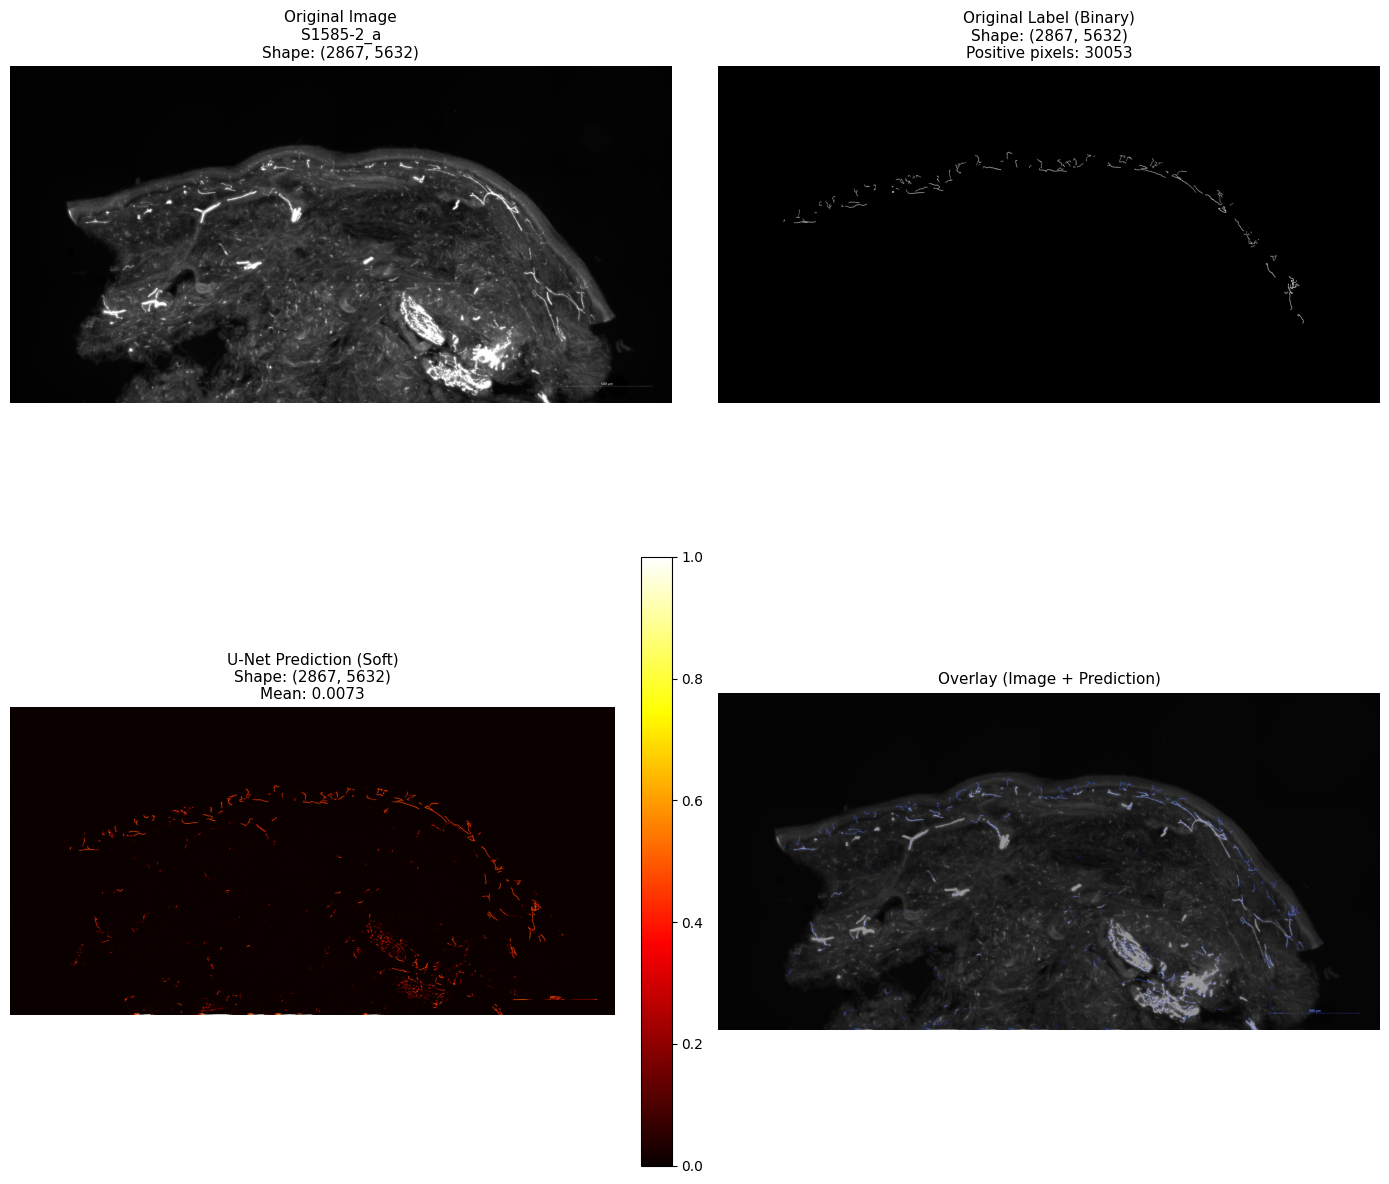


✅ U-Net 預測結果已保存到: ../models/S1585-2_a_unet_prediction.png


In [136]:
# 可視化 U-Net 預測結果
if original_label_path.exists():
    original_label = cv2.imread(str(original_label_path), cv2.IMREAD_GRAYSCALE)
    
    # Resize label 到與 image 相同尺寸
    if original_label.shape != original_image.shape:
        original_label = cv2.resize(
            original_label, 
            (original_image.shape[1], original_image.shape[0]), 
            interpolation=cv2.INTER_NEAREST
        )
    
    # 可視化
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    # 原始圖像
    axes[0, 0].imshow(original_image, cmap='gray')
    axes[0, 0].set_title(f'Original Image\n{sample_id}\nShape: {original_image.shape}', fontsize=11)
    axes[0, 0].axis('off')
    
    # 原始標籤（二值）
    axes[0, 1].imshow(original_label, cmap='gray')
    axes[0, 1].set_title(f'Original Label (Binary)\nShape: {original_label.shape}\nPositive pixels: {np.sum(original_label > 0)}', fontsize=11)
    axes[0, 1].axis('off')
    
    # U-Net 預測（軟標籤）
    im = axes[1, 0].imshow(predicted_label, cmap='hot', vmin=0, vmax=1)
    axes[1, 0].set_title(f'U-Net Prediction (Soft)\nShape: {predicted_label.shape}\nMean: {predicted_label.mean():.4f}', fontsize=11)
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
    
    # 疊加顯示
    overlay_rgb = cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB)
    pred_colored = (predicted_label * 255).astype(np.uint8)
    pred_colored = cv2.applyColorMap(pred_colored, cv2.COLORMAP_HOT)
    overlay_rgb = cv2.addWeighted(overlay_rgb, 0.6, pred_colored, 0.4, 0)
    
    axes[1, 1].imshow(overlay_rgb)
    axes[1, 1].set_title(f'Overlay (Image + Prediction)', fontsize=11)
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"{sample_id}_unet_prediction.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ U-Net 預測結果已保存到: {SAVE_DIR / f'{sample_id}_unet_prediction.png'}")

else:
    print("⚠️  找不到原始標籤")

In [137]:
# 評估 U-Net 預測結果
print("="*60)
print(f"評估 U-Net 預測結果: {sample_id}")
print("="*60)

if original_label is not None:
    print(f"\n1️⃣  硬 Dice 係數（閾值二值化）:")
    print("-"*60)
    
    # 嘗試不同的閾值
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    best_dice = 0
    best_threshold = 0
    
    for thresh in thresholds:
        dice, pred_bin, target_bin, intersection, pred_sum, target_sum = calculate_dice_coefficient(
            predicted_label, original_label, threshold=thresh
        )
        print(f"  閾值 {thresh:.1f}: Dice = {dice:.4f} "
              f"(交集: {int(intersection)}, 預測: {int(pred_sum)}, 真實: {int(target_sum)})")
        
        if dice > best_dice:
            best_dice = dice
            best_threshold = thresh
    
    print(f"\n  ✅ 最佳閾值: {best_threshold:.1f}, Dice = {best_dice:.4f}")
    
    # 計算軟 Dice
    print(f"\n2️⃣  軟 Dice 係數（不二值化）:")
    print("-"*60)
    soft_dice = calculate_soft_dice(predicted_label, original_label)
    print(f"  軟 Dice = {soft_dice:.4f}")
    
    # 額外的評估指標
    print(f"\n3️⃣  額外評估指標（使用最佳閾值 {best_threshold:.1f}）:")
    print("-"*60)
    
    # 使用最佳閾值計算
    dice, pred_bin, target_bin, intersection, pred_sum, target_sum = calculate_dice_coefficient(
        predicted_label, original_label, threshold=best_threshold
    )
    
    # True Positives, False Positives, False Negatives
    tp = intersection
    fp = pred_sum - intersection
    fn = target_sum - intersection
    tn = np.sum((pred_bin == 0) & (target_bin == 0))
    
    # 計算 Precision, Recall, F1
    precision = tp / (tp + fp + 1e-5)
    recall = tp / (tp + fn + 1e-5)
    f1 = 2 * precision * recall / (precision + recall + 1e-5)
    iou = tp / (tp + fp + fn + 1e-5)
    
    print(f"  Precision (精確率): {precision:.4f}")
    print(f"  Recall (召回率):    {recall:.4f}")
    print(f"  F1 Score:           {f1:.4f}")
    print(f"  IoU (交並比):       {iou:.4f}")
    print(f"")
    print(f"  True Positives:     {int(tp):,}")
    print(f"  False Positives:    {int(fp):,}")
    print(f"  False Negatives:    {int(fn):,}")
    print(f"  True Negatives:     {int(tn):,}")
    
    # 計算像素準確率
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    print(f"")
    print(f"  Pixel Accuracy:     {accuracy:.4f}")
    
    print("\n" + "="*60)
    print("✅ U-Net 預測評估完成！")
    print("="*60)
    
    # 總結比較
    print(f"\n📊 評估總結:")
    print(f"  樣本: {sample_id}")
    print(f"  圖像尺寸: {original_image.shape}")
    print(f"  最佳 Dice 係數: {best_dice:.4f} (閾值: {best_threshold:.1f})")
    print(f"  軟 Dice 係數: {soft_dice:.4f}")
    print(f"  IoU: {iou:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
else:
    print("⚠️  找不到原始標籤，無法進行評估")

評估 U-Net 預測結果: S1585-2_a

1️⃣  硬 Dice 係數（閾值二值化）:
------------------------------------------------------------
  閾值 0.3: Dice = 0.3955 (交集: 19860, 預測: 70376, 真實: 30053)
  閾值 0.4: Dice = 0.4022 (交集: 16070, 預測: 49857, 真實: 30053)
  閾值 0.5: Dice = 0.3644 (交集: 11280, 預測: 31853, 真實: 30053)
  閾值 0.6: Dice = 0.2225 (交集: 5028, 預測: 15148, 真實: 30053)
  閾值 0.7: Dice = 0.0292 (交集: 528, 預測: 6098, 真實: 30053)

  ✅ 最佳閾值: 0.4, Dice = 0.4022

2️⃣  軟 Dice 係數（不二值化）:
------------------------------------------------------------
  軟 Dice = 0.1578

3️⃣  額外評估指標（使用最佳閾值 0.4）:
------------------------------------------------------------
  Precision (精確率): 0.3223
  Recall (召回率):    0.5347
  F1 Score:           0.4022
  IoU (交並比):       0.2517

  True Positives:     16,070
  False Positives:    33,787
  False Negatives:    13,983
  True Negatives:     16,083,104

  Pixel Accuracy:     0.9970

✅ U-Net 預測評估完成！

📊 評估總結:
  樣本: S1585-2_a
  圖像尺寸: (2867, 5632)
  最佳 Dice 係數: 0.4022 (閾值: 0.4)
  軟 Dice 係數: 0.1578
  IoU: 0.2517